## 1. Configuración y carga

Todos los **hiperparámetros del pipeline** se definen en un único bloque para que las decisiones sean explícitas.

In [28]:
import os, gc, json, time, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})

SEED = 42
rng = np.random.default_rng(SEED)

# Decisiones
CFG = dict(
    MIN_LEN = 3, # min. transacciones para que un remitente entre al dataset
    MAX_LEN = 64, # longitud de ventana (padding / truncamiento)
    CAP_WINDOWS = 20, # tope de ventanas por remitente
    INST_TX_THR = 500, # umbral para marcar cuenta institucional
    CLIP_SIGMA = 5.0, # recorte de las features estandarizadas
    SPLITS = (0.70, 0.15, 0.15),
    NEG_POS_RATIO= 10, # submuestreo de negativos para la Etapa B
    SEED = SEED,
)
print(json.dumps(CFG, indent=2))

{
  "MIN_LEN": 3,
  "MAX_LEN": 64,
  "CAP_WINDOWS": 20,
  "INST_TX_THR": 500,
  "CLIP_SIGMA": 5.0,
  "SPLITS": [
    0.7,
    0.15,
    0.15
  ],
  "NEG_POS_RATIO": 10,
  "SEED": 42
}


In [29]:
# Rutas. 
CANDIDATES = [Path("/data"), Path("data"), Path("./data"), Path("../data"), Path("/content/data")]
DATA_DIR = next((p for p in CANDIDATES if p.exists()), None)

# En Colab: descomentar el bloque de descarga.
# -----------------------------------------------------------------------
# !pip -q install kagglehub
# import kagglehub, shutil
# p = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")
# DATA_DIR = Path(p)
# -----------------------------------------------------------------------

assert DATA_DIR is not None, "No se encontro la carpeta de datos."
HI_TRANS = DATA_DIR / "HI-Small_Trans.csv"
HI_PATT  = DATA_DIR / "HI-Small_Patterns.txt"
PAYSIM   = DATA_DIR / "PS_20174392719_1491204439457_log.csv"

OUT_DIR = Path("artifacts"); OUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
for p in (HI_TRANS, HI_PATT, PAYSIM):
    print(f"  {p.name:<45} {'OK' if p.exists() else 'FALTA':<6}"
          f" {p.stat().st_size/1e6:>8,.1f} MB" if p.exists() else f"  {p.name:<45} FALTA")
T0 = time.time()

DATA_DIR: C:\Users\juand\Desktop\deep-learning\dl-project2\data
  HI-Small_Trans.csv                            OK        475.7 MB
  HI-Small_Patterns.txt                         OK          0.3 MB
  PS_20174392719_1491204439457_log.csv          OK        493.5 MB


In [30]:
COLS = ["timestamp", "from_bank", "from_acct", "to_bank", "to_acct", "amt_recv", "cur_recv", "amt_paid", "cur_paid", "fmt", "is_laundering"]

df = pd.read_csv(
    HI_TRANS, skiprows=1, names=COLS,
    dtype={"from_bank": "category", "from_acct": "category", "to_bank": "category", "to_acct": "category",
           "cur_recv": "category", "cur_paid": "category", "fmt": "category", "amt_recv": "float64", 
           "amt_paid": "float64", "is_laundering": "int8"
        }
)

df["ts"] = pd.to_datetime(df["timestamp"], format="%Y/%m/%d %H:%M")
df = df.drop(columns=["timestamp"])

print(f"transacciones: {len(df):,}")
print(f"memoria: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"periodo: {df['ts'].min()}  ->  {df['ts'].max()}")
print(f"valores nulos: {int(df.isna().sum().sum())}")
print()
print(df.head(3).to_string())

transacciones: 5,078,345
memoria: 0.25 GB
periodo: 2022-09-01 00:00:00  ->  2022-09-18 16:18:00
valores nulos: 0

  from_bank  from_acct to_bank    to_acct  amt_recv   cur_recv  amt_paid   cur_paid           fmt  is_laundering                  ts
0       010  8000EBD30     010  8000EBD30   3697.34  US Dollar   3697.34  US Dollar  Reinvestment              0 2022-09-01 00:20:00
1     03208  8000F4580     001  8000F5340      0.01  US Dollar      0.01  US Dollar        Cheque              0 2022-09-01 00:20:00
2     03209  8000F4670   03209  8000F4670  14675.57  US Dollar  14675.57  US Dollar  Reinvestment              0 2022-09-01 00:00:00


## 2. Evidencia para la selección del subconjunto

### 2.1 Por qué se descarta PaySim

El enunciado propone **PaySim** como dataset principal. La siguiente verificación muestra que su estructura es incompatible con el requisito de construir **secuencias por remitente**.


In [31]:
if PAYSIM.exists():
    ps = pd.read_csv(PAYSIM, usecols=["nameOrig", "isFraud", "type"],
                     dtype={"nameOrig": "object", "isFraud": "int8", "type": "category"})
    oc = ps["nameOrig"].value_counts()
    print("PAYSIM")
    print(f"- transacciones: {len(ps):,}")
    print(f"- remitentes unicos (nameOrig): {len(oc):,}")
    print(f"- transacciones por remitente: {len(ps)/len(oc):.3f}")
    print(f"- remitentes con 1 sola tx: {int((oc == 1).sum()):,}"
          f"  ({100*(oc == 1).mean():.2f} %)")
    print(f"- maximo de tx de un remitente: {int(oc.max())}")
    fo = ps.loc[ps['isFraud'] == 1, 'nameOrig']
    print(f"- remitentes con fraude: {fo.nunique():,}"
          f"  |  de ellos con 1 sola tx: {int((oc.loc[fo.unique()] == 1).sum()):,}")
    del ps, oc, fo; _ = gc.collect()
else:
    print("PaySim no disponible en esta ejecucion.")

PAYSIM
- transacciones: 6,362,620
- remitentes unicos (nameOrig): 6,353,307
- transacciones por remitente: 1.001
- remitentes con 1 sola tx: 6,344,009  (99.85 %)
- maximo de tx de un remitente: 3
- remitentes con fraude: 8,213  |  de ellos con 1 sola tx: 8,185


**Decisión 1.** PaySim queda excluido del modelado. Con **1.00 transacciones por remitente**, no existe historial que secuenciar: cada secuencia tendría longitud 1 y el sistema degeneraría en un clasificador de transacciones aisladas, enfoque que el proyecto busca superar. Además, su etiqueta `isFraud` corresponde a fraude por toma de cuenta, no a lavado.

Se utiliza **IBM AML HI-Small**, que promedia **10.2 transacciones por remitente**, incluye etiquetas de lavado y 370 patrones tipificados para el análisis de interpretabilidad del Componente 3.

Se elige **Small** (5.1 M transacciones) sobre *Medium* (32 M) y *Large* (180 M) por el límite de **30 minutos de reproducción en una T4**, y **HI** sobre *LI* porque esta última contiene la mitad de casos positivos, dejando pocas secuencias etiquetadas para la Etapa B.


### 2.2 Estructura de la etiqueta y artefactos del dataset

Antes de diseñar **features**, se evalúa qué tan separables son las clases con variables crudas, ya que esto condiciona la interpretación del experimento de ablación.


In [32]:
n = len(df)
n_pos = int(df["is_laundering"].sum())
sender_tx = df.groupby("from_acct", observed=True).size()
pos_senders = set(df.loc[df["is_laundering"] == 1, "from_acct"].unique())

print(f"transacciones marcadas como lavado: {n_pos:,}  ({100*n_pos/n:.4f} %)")
print(f"remitentes: {len(sender_tx):,}")
print(f"remitentes con >=1 tx marcada: {len(pos_senders):,}"
      f"  ({100*len(pos_senders)/len(sender_tx):.4f} %)")
print(f"tx ilicitas por remitente positivo: {n_pos/len(pos_senders):.2f}")

transacciones marcadas como lavado: 5,177  (0.1019 %)
remitentes: 496,995
remitentes con >=1 tx marcada: 3,376  (0.6793 %)
tx ilicitas por remitente positivo: 1.53


**Observación crítica.** Un remitente positivo tiene en promedio **1.5 transacciones ilícitas**. En una ventana de decenas de operaciones, esto descarta usar el error de reconstrucción **promediado** como score de anomalía en la Etapa A, ya que las transacciones anómalas se diluirían entre las normales.

Dado lo anterior, el Componente 2 usará el **máximo** o la media de los *top-k* errores por transacción.


In [33]:
fmt_ct = pd.crosstab(df["fmt"], df["is_laundering"], normalize="columns") * 100
fmt_ct.columns = ["% en normales", "% en ilicitas"]
print("FORMATO DE PAGO POR CLASE:")
print(fmt_ct.round(2).sort_values("% en ilicitas", ascending=False).to_string())
print()
g = df.groupby("is_laundering")["amt_paid"]

print("MONTO PAGADO POR CLASE:")
print(pd.DataFrame({"n": g.size(), "mediana": g.median().round(2), "p99": g.quantile(.99).round(0)}).to_string())
print()
ordenes = np.log10(df["amt_paid"].max() / df["amt_paid"].min())
print(f"rango de montos: {df['amt_paid'].min():.2e}  a  {df['amt_paid'].max():.2e}"
      f"  ({ordenes:.0f} ordenes de magnitud)")
print("Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.")

FORMATO DE PAGO POR CLASE:
              % en normales  % en ilicitas
fmt                                       
ACH                   11.75          86.59
Cheque                36.74           6.26
Credit Card           26.08           3.98
Cash                   9.67           2.09
Bitcoin                2.88           1.08
Reinvestment           9.48           0.00
Wire                   3.39           0.00

MONTO PAGADO POR CLASE:
                     n  mediana         p99
is_laundering                              
0              5073168  1410.99  13515035.0
1                 5177  8667.21  23420047.0

rango de montos: 1.00e-06  a  1.05e+12  (18 ordenes de magnitud)
Se transforma con log1p antes de estandarizar; sin log, la escala del monto domina cualquier distancia en el espacio de features.


**Artefacto documentado.** El formato **ACH** concentra el **86.6 %** de las transacciones ilícitas frente al **11.8 %** de las normales. Además, *Reinvestment* y *Wire* no aparecen en casos ilícitos, y todas las operaciones del archivo de patrones son ACH.

Un clasificador podría obtener métricas altas usando solo esta variable, sin aprender estructura temporal. Por ello, aunque el formato se conserva como **feature**, el Componente 2 incluirá una ablación **sin el bloque de formato de pago** para comprobar que el modelo no depende de este atajo.


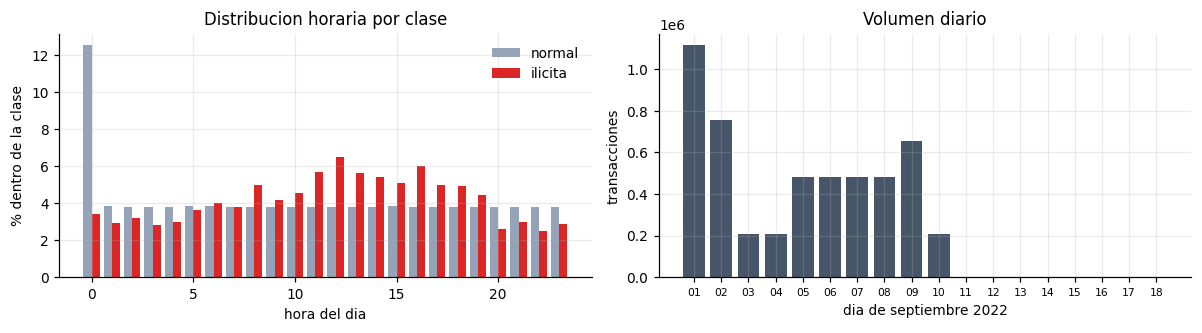

tx en la hora 0 (normales): 12.51 %   (ilicitas): 3.40 %
tx del 1 al 10 de septiembre: 99.98 % del total


In [34]:
hr = pd.crosstab(df["ts"].dt.hour, df["is_laundering"], normalize="columns") * 100
day = df["ts"].dt.date.value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.1))
ax[0].bar(hr.index - 0.2, hr[0], width=0.4, label="normal", color="#94a3b8")
ax[0].bar(hr.index + 0.2, hr[1], width=0.4, label="ilicita", color="#dc2626")
ax[0].set_xlabel("hora del dia"); ax[0].set_ylabel("% dentro de la clase")
ax[0].set_title("Distribucion horaria por clase"); ax[0].legend(frameon=False)

ax[1].bar(range(len(day)), day.values, color="#475569")
ax[1].set_xticks(range(len(day)))
ax[1].set_xticklabels([d.strftime("%d") for d in day.index], fontsize=7)
ax[1].set_xlabel("dia de septiembre 2022"); ax[1].set_ylabel("transacciones")
ax[1].set_title("Volumen diario")
plt.tight_layout(); plt.show()

print(f"tx en la hora 0 (normales): {hr.loc[0,0]:.2f} %   (ilicitas): {hr.loc[0,1]:.2f} %")
print(f"tx del 1 al 10 de septiembre: {100*day.iloc[:10].sum()/day.sum():.2f} % del total")

**Artefactos adicionales.** El **12.5 %** de las transacciones normales ocurre a la hora 0, frente al **3.8 %** en cualquier otra hora, debido al lote de inicialización del simulador concentrado el 1 de septiembre.

Además, el **99.98 %** del volumen ocurre en los primeros diez días, con una cola residual hasta el día 18. Esto descarta una partición temporal, ya que los patrones de lavado abarcan varios días y un corte cronológico podría dividirlos.


## 3. Evidencia para la longitud de secuencia

La distribución de longitudes determina dos decisiones: el **mínimo de transacciones por remitente** para entrar al dataset y la **longitud de ventana** a utilizar.


In [35]:
q = [.5, .75, .9, .95, .99, .999, 1.]
print("TRANSACCIONES POR REMITENTE")
print(f"  media {sender_tx.mean():.2f} | mediana {sender_tx.median():.0f} | "
      f"max {sender_tx.max():,}")
print("  percentiles:", {f"p{int(p*1000)/10}": int(sender_tx.quantile(p)) for p in q})

print()
print("EFECTO DEL MINIMO DE LONGITUD")
print(f"{'min_len':>7} | {'remitentes':>11} | {'positivos':>9} | {'% pos':>7} | {'% tx':>6}")
print("-" * 56)
for k in [1, 2, 3, 4, 5, 8, 10, 20]:
    keep = sender_tx[sender_tx >= k]
    npos = len(set(keep.index) & pos_senders)
    print(f"{k:>7} | {len(keep):>11,} | {npos:>9,} | "
          f"{100*npos/len(keep):>6.3f}% | {100*keep.sum()/n:>5.1f}%")

TRANSACCIONES POR REMITENTE
  media 10.22 | mediana 2 | max 168,672
  percentiles: {'p50.0': 2, 'p75.0': 5, 'p90.0': 29, 'p95.0': 46, 'p99.0': 92, 'p99.9': 159, 'p100.0': 168672}

EFECTO DEL MINIMO DE LONGITUD
min_len |  remitentes | positivos |   % pos |   % tx
--------------------------------------------------------
      1 |     496,995 |     3,376 |  0.679% | 100.0%
      2 |     344,245 |     3,254 |  0.945% |  97.0%
      3 |     185,993 |     2,758 |  1.483% |  90.8%
      4 |     142,306 |     2,085 |  1.465% |  88.2%
      5 |     128,779 |     1,626 |  1.263% |  87.1%
      8 |     115,279 |     1,255 |  1.089% |  85.6%
     10 |     110,008 |     1,185 |  1.077% |  84.7%
     20 |      76,833 |       887 |  1.154% |  75.6%


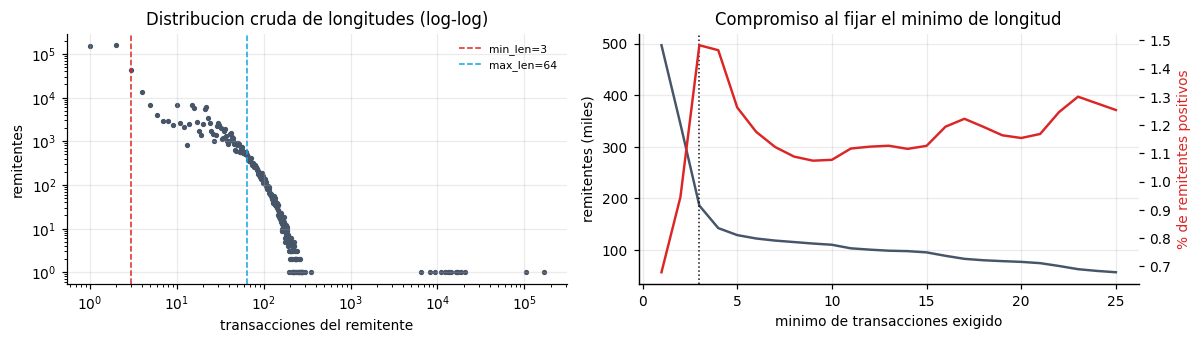

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
vc = sender_tx.value_counts().sort_index()
ax[0].scatter(vc.index, vc.values, s=6, color="#475569")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("transacciones del remitente"); ax[0].set_ylabel("remitentes")
ax[0].set_title("Distribucion cruda de longitudes (log-log)")
ax[0].axvline(CFG["MIN_LEN"], color="#dc2626", ls="--", lw=1, label=f"min_len={CFG['MIN_LEN']}")
ax[0].axvline(CFG["MAX_LEN"], color="#0ea5e9", ls="--", lw=1, label=f"max_len={CFG['MAX_LEN']}")
ax[0].legend(frameon=False, fontsize=7)

ks = np.arange(1, 26)
rem = [int((sender_tx >= k).sum()) for k in ks]
pct = [100 * len(set(sender_tx[sender_tx >= k].index) & pos_senders) / r
       for k, r in zip(ks, rem)]
a2 = ax[1]; a3 = a2.twinx()
a2.plot(ks, np.array(rem) / 1000, color="#475569", lw=1.6, label="remitentes (miles)")
a3.plot(ks, pct, color="#dc2626", lw=1.6, label="% positivos")
a2.axvline(CFG["MIN_LEN"], color="#111", ls=":", lw=1)
a2.set_xlabel("minimo de transacciones exigido"); a2.set_ylabel("remitentes (miles)")
a3.set_ylabel("% de remitentes positivos", color="#dc2626")
a3.grid(False)
a2.set_title("Compromiso al fijar el minimo de longitud")
plt.tight_layout(); plt.show()

In [37]:
inst = sender_tx[sender_tx > CFG["INST_TX_THR"]]
print(f"CUENTAS INSTITUCIONALES (> {CFG['INST_TX_THR']} tx)")
print(f" - cuentas            : {len(inst)}")
print(f" - transacciones      : {int(inst.sum()):,}  ({100*inst.sum()/n:.1f} % del total)")
print(f" - de ellas positivas : {len(set(inst.index) & pos_senders)}")
print()
print("  - top 8 por volumen:")
for a, c in inst.sort_values(ascending=False).head(8).items():
    print(f"   * {a:<12} {c:>9,} tx")
gap_lo = int(sender_tx[sender_tx <= CFG["INST_TX_THR"]].max())
gap_hi = int(inst.min()) if len(inst) else 0
print()
print(f"  hueco en la distribucion: nada entre {gap_lo:,} y {gap_hi:,} transacciones")
print("  Son dos poblaciones distintas, no una cola continua")
INST_ACCTS = set(inst.index)

CUENTAS INSTITUCIONALES (> 500 tx)
 - cuentas            : 15
 - transacciones      : 449,859  (8.9 % del total)
 - de ellas positivas : 15

  - top 8 por volumen:
   * 100428660      168,672 tx
   * 1004286A8      103,018 tx
   * 100428978       20,497 tx
   * 1004286F0       18,663 tx
   * 100428780       17,264 tx
   * 1004289C0       16,794 tx
   * 100428810       16,426 tx
   * 1004287C8       14,174 tx

  hueco en la distribucion: nada entre 351 y 6,431 transacciones
  Son dos poblaciones distintas, no una cola continua


**Decisión 2 | mínimo de 3 transacciones.** Descarta al **63 % de las cuentas**, pero conserva el **90.8 % del volumen** y eleva la proporción de remitentes positivos de **0.68 % a 1.48 %**. Un remitente con una o dos operaciones tampoco ofrece historial suficiente para un análisis de cumplimiento, por lo que el criterio es defendible operativa y estadísticamente.

**Decisión 3 | cuentas institucionales.** Quince cuentas superan las **500 transacciones** y concentran el **8.9 % del volumen**, con hasta **168 mil operaciones** cada una. No se eliminan porque son hubs relevantes, pero se marcan como cohorte separada para reportar el desempeño con y sin ellas. Su peso en el entrenamiento se controla mediante el tope de ventanas de la Decisión 5.
